In [102]:
from lib.contact_settings import *
from lib.contact_material import material
from lib.geoLib.contact_wheel_rail import wheel, rail
from lib.dynLib.contact_dyn_state import dynamic_state
from lib.normLib.contact_methods import eqv_el_normal_contact, kik_pio_normal_contact
from lib.normLib.contact_solver import NormalContactSolver

In [ ]:
dy = -3e-3

Wheel = wheel()
Rail = rail(rail_inclination=30)

material_model = material()

n_patches = 3
contact_eq = NormalContactSolver(eqv_el_normal_contact(), n_patches)

new_state = dynamic_state(state_y=dy, state_z=1e-4)
Wheel.set_dynamic_state(new_state)
Wheel.calculate_position()

contact_eq.patch_search(Wheel, Rail, material_model)

In [104]:
print(Wheel.wheel_radius)

[[0.67713    0.47182419]
 [0.67713095 0.47183188]
 [0.6771319  0.47183956]
 ...
 [0.8072718  0.45734596]
 [0.80727935 0.45734545]
 [0.8072869  0.45734494]]


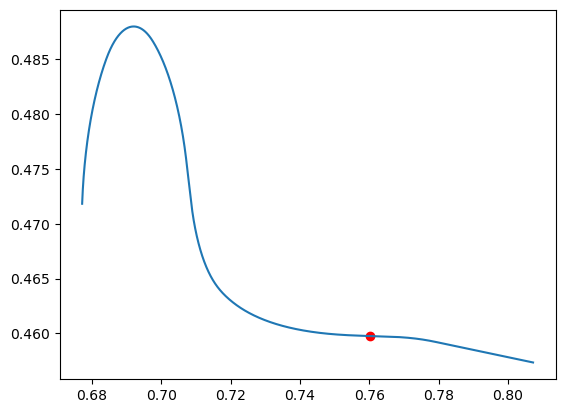

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(Wheel.wheel_radius[:, 0], Wheel.wheel_radius[:, 1])

radius_inerpolator = PchipInterpolator(
    Wheel.wheel_radius[:, 0], Wheel.wheel_radius[:, 1]
)
try:
    contact_radius = radius_inerpolator(contact_eq.contact_patches[0].centroid_wheel[0])
    ax.scatter(contact_eq.contact_patches[0].centroid_wheel[0], contact_radius, c="red")
except:
    contact_radius = None

In [ ]:
delta_r = -(contact_radius - Wheel.r0) / Wheel.r0
print("Delta r / r0: ", delta_r)

Delta r / r0:  0.0005197722134805115


In [107]:
contact_eq.contact_patches[0].contact_angle

0.009397173706056515

In [ ]:
c11_tab = np.array(
    [
        [
            2.51,
            2.59,
            2.68,
            2.78,
            2.88,
            2.98,
            3.09,
            3.19,
            3.29,
            3.4,
            3.61,
            3.65,
            3.82,
            4.06,
            4.37,
            4.84,
            5.57,
            6.96,
            10.7,
        ],
        [
            3.31,
            3.37,
            3.44,
            3.53,
            3.62,
            3.72,
            3.81,
            3.91,
            4.01,
            4.12,
            4.22,
            4.36,
            4.54,
            4.78,
            5.10,
            5.57,
            6.34,
            7.78,
            11.7,
        ],
        [
            4.85,
            4.81,
            4.8,
            4.82,
            4.83,
            4.91,
            4.97,
            5.05,
            5.12,
            5.2,
            5.3,
            5.42,
            5.58,
            5.8,
            6.11,
            6.57,
            7.34,
            8.82,
            12.9,
        ],
    ]
)

In [113]:
c11_interpolator = PchipInterpolator(
    np.array([0, 0.25, 0.5]), c11_tab
)

In [118]:
c11_material = c11_interpolator(material_model.Shear_Modulus)

In [120]:
a = contact_eq.contact_patches[0].semi_axis_a
b = contact_eq.contact_patches[0].semi_axis_b

c11_interpolator_ab = PchipInterpolator(abratio, c11_material)
c11_final = c11_interpolator_ab(a/b)
print("C11 final: ", c11_final)

C11 final:  4.393930133304707
